In [4]:
%reload_ext autoreload
%autoreload 2

import os
from pathlib import Path
import sys

print(Path().cwd())
os.chdir(Path(os.getcwd()).parent)
print(Path().cwd())

sys.path.insert(0, str(Path.cwd() / "CLI-Demos"))
sys.path.insert(0, str(Path.cwd() / "CLI-Demos"/"medsam2_function"))

/home/ahmed-el-kaffas/Documents/Github/QuantUS/engines/ceus/CLI-Demos
/home/ahmed-el-kaffas/Documents/Github/QuantUS/engines/ceus


## Select Contrast-Enhanced Ultrasound (CEUS) Cine and Parser

In [5]:
from src.image_loading.options import get_scan_loaders

print("Available scan loaders:", list(get_scan_loaders().keys()))

Available scan loaders: ['avi', 'mp4', 'nifti']


In [6]:
import pandas as pd

from extract_finetune_dataset import find_bmode_file, find_ceus_file, find_voi_file

MASTER_CSV = "/media/ahmed-el-kaffas/20TB-HDD/Yuanshan/3DMPUS/Motion_compensation_results/Motion Compensation Comparison 4 patients(MedSAM2).csv"

df = pd.read_csv(MASTER_CSV)
row = df.iloc[30]

case_key = f"{row['Site']}-{row['Patient Number']}-{row['Visit']}-{row['Bolus']}"
print(f"\n=== {case_key} ===")

try:
    bmode_path = find_bmode_file(row["Data Dir"], row["Visit"], row["Bolus"])
    ceus_path  = find_ceus_file(bmode_path)
    seg_path_  = find_voi_file(row["Data Dir"], row["Visit"], row["Bolus"])
    inputs = {"bmode": bmode_path, "ceus": ceus_path, "seg": seg_path_}
    print(f"  bmode: {os.path.basename(inputs['bmode'])}")
    print(f"  ceus : {os.path.basename(inputs['ceus'])}")
    print(f"  seg  : {os.path.basename(inputs['seg'])}")
except FileNotFoundError as e:
    inputs = {"bmode": None, "ceus": None, "seg": None}
    print(f"  [SKIP] {e}")



=== TJU-P06-V01-CEUS1 ===
  bmode: TJU-P6-V01-CEUS1_14.47.38_mf_sip_capture_50_2_1_0_BMODE.nii
  ceus : TJU-P6-V01-CEUS1_14.47.38_mf_sip_capture_50_2_1_0_CEUS.nii
  seg  : TJU-P6-V01-CEUS1-MC_VOI.nii.gz


In [7]:
scan_type = 'nifti'

# Takes the NIfTI files as input for contrast enhanced ultrasound (CEUS) scans
CEUS_scan_path = inputs['ceus']
bmode_scan_path = inputs['bmode']
scan_loader_kwargs = {
}

In [8]:
from src.entrypoints import scan_loading_step

image_data = scan_loading_step(scan_type, CEUS_scan_path, **scan_loader_kwargs)
bmode_image_data = scan_loading_step(scan_type, bmode_scan_path, **scan_loader_kwargs)

## Load Segmentation

Assumes same segmentation for each frame

In [9]:
from src.seg_loading.options import get_seg_loaders

print("Available segmentation loaders:", list(get_seg_loaders().keys()))

Available segmentation loaders: ['nifti', 'load_bolus_mask']


In [10]:
seg_type = 'nifti'

seg_path = inputs['seg']
seg_loader_kwargs = {}

In [11]:
from src.entrypoints import seg_loading_step

# Testing the motion compensation, right now is hard coded
seg_data = seg_loading_step(seg_type, image_data, seg_path, CEUS_scan_path, **seg_loader_kwargs)

## Extract one B-mode frame for fine-tuning annotation

Save a single timepoint from `bmode_scan_path` as `image.nii.gz` + `image.json` (plus an empty `segmentations/` folder), in the layout used for MedSAM2 fine-tuning data prep. Pick `frame_idx` after reviewing the volume in the 2D/3-plane or napari viewer above — a frame where the tumor and tracked bbox look well-conditioned.

In [ ]:
from extract_finetune_dataset import extract_bmode_and_ceus_frame

print(f"BMODE: {bmode_scan_path}")
print(f"CEUS:  {CEUS_scan_path}")
print(f"  {bmode_image_data.pixel_data.shape[-1]} frames available")

# ── Set these for the case you're extracting ─────────────────────────────────
site = bmode_scan_path.split('/')[-1].split('-')[0]
patient =  bmode_scan_path.split('/')[-1].split('-')[1]
visits =  bmode_scan_path.split('/')[-1].split('-')[2]

native_subject_id = site+'-'+patient+'-'+visits
frame_idx         = 0                              # <- pick after reviewing above
# subject_id        = "subject_000001"                # <- one folder per patient
# sequence_id       = "sequence_001"                   # <- based on the bolus number
# output_root       = "/media/ahmed-el-kaffas/20TB-HDD/Yuanshan/3DMPUS/MedSAM2_finetune_data"

# out_dir = extract_bmode_and_ceus_frame(
#     bmode_path=bmode_scan_path,
#     ceus_path=CEUS_scan_path,
#     frame_idx=frame_idx,
#     subject_id=subject_id,
#     sequence_id=sequence_id,
#     output_root=output_root,
#     native_subject_id=native_subject_id,
# )
print(f"Saved frame {frame_idx} (image.* + image_ceus.*) -> {out_dir}")

## Batch-generate volumes from manifest.csv

Reads `manifest.csv` (produced by `extract_finetune_dataset.py manifest` from the motion-compensation CSV) and, for every row that has a reviewed `frame_idx` filled in, extracts that frame from both the B-mode and CEUS volumes. No intensity normalization is applied — the saved B-mode volume is the raw pixel data; use ITK-SNAP's own contrast/window-level controls when viewing or annotating it.

In [ ]:
from extract_finetune_dataset import extract_all

manifest_path = "/media/ahmed-el-kaffas/20TB-HDD/Yuanshan/3DMPUS/MedSAM2_finetune_data/manifest.csv"
output_root   = "/media/ahmed-el-kaffas/20TB-HDD/Yuanshan/3DMPUS/MedSAM2_finetune_data"

extract_all(manifest_path, output_root)

# 2D fixed-z temporal evaluation set

A single axial plane (one fixed `z`) pulled out of the 4D B-mode and CEUS
series across time, with an ROI drawn by hand on each frame. Saves to
`/media/ahmed-el-kaffas/20TB-HDD/Yuanshan/3DMPUS/MedSAM2_2D_temporal_eval`.

Requires the **ipympl** backend for mouse events — the `%matplotlib widget`
line below must run before the annotator is created, and if the notebook was
already running with inline plots you need to restart the kernel first.

Two things to carry into the analysis, both consequences of holding `z` fixed
while the lesion moves with respiration:

- Some frames will have the lesion partly or entirely **out of plane**. Use
  **Mark empty** rather than skipping them — an empty ROI is recorded as
  annotated, which makes those frames the false-positive test. Dice is
  undefined there, so report them separately instead of averaging them in.
- The lesion's cross-section shrinks as the plane drifts off centre, and Dice
  is biased against small objects. `gt_area_px` is saved per frame so a dip in
  Dice can be checked against cross-section size before being read as
  temporal degradation.

In [10]:
%matplotlib widget

from medsam2_2d_temporal_roi import (
    extract_axial_video, suggest_z_from_voi, lookup_case_ids, AxialRoiAnnotator,
)

OUTPUT_ROOT_2D    = "/media/ahmed-el-kaffas/20TB-HDD/Yuanshan/3DMPUS/MedSAM2_2D_temporal_eval"
FINETUNE_MANIFEST = "/media/ahmed-el-kaffas/20TB-HDD/Yuanshan/3DMPUS/MedSAM2_finetune_data/manifest.csv"
N_FRAMES = 20

## Step 1 — Pick the slice and pull the axial video

`suggest_z_from_voi` returns the reference VOI's centroid slice, which keeps
the lesion inside the fixed plane for as long as possible; override `z` by
hand if a different slice frames the lesion better.

Pass the master CSV row's `Site` / `Patient Number` / `Visit` / `Bolus`
through — those four fields are what tie this case back to
`MedSAM2_finetune_data` (see Step 2). Pass `frame_indices=` to reuse a
specific frame set; otherwise `N_FRAMES` are spread evenly across the series.
Only the requested planes are read, so this is quick despite the multi-GB
sources.

In [11]:
voi_path = find_voi_file(row["Data Dir"], row["Visit"], row["Bolus"])
# z = suggest_z_from_voi(voi_path)
z = 170 # TJU-P06
print(f"reference VOI centroid slice: z = {z}")

video = extract_axial_video(
    bmode_path=inputs["bmode"],
    ceus_path=inputs["ceus"],
    z=z,
    n_frames=N_FRAMES,             # or: frame_indices=[...]
    site=row["Site"],
    patient_number=row["Patient Number"],
    visit=row["Visit"],
    bolus=row["Bolus"],
)

print(f"B-mode {video['bmode'].shape}  CEUS {video['ceus'].shape}  (T, H, W)")
print(f"frames {video['frame_indices']}")
print(f"times  {[round(t, 1) for t in video['time_s']]} s")

reference VOI centroid slice: z = 170
B-mode (20, 266, 360)  CEUS (20, 266, 360)  (T, H, W)
frames [0, 24, 49, 73, 97, 122, 146, 170, 195, 219, 243, 267, 292, 316, 340, 365, 389, 413, 438, 462]
times  [0.0, 10.2, 20.8, 31.0, 41.2, 51.8, 62.0, 72.2, 82.8, 93.0, 103.2, 113.4, 124.0, 134.2, 144.4, 155.0, 165.2, 175.4, 186.0, 196.2] s


## Step 2 — Draw the ROIs

Passing `finetune_manifest=` resolves this case's canonical `subject_id` /
`sequence_id` out of `MedSAM2_finetune_data/manifest.csv`, so the 2D set lines
up with the fine-tuning tree by construction instead of by a typed string.
**Don't type those ids by hand** — neither is guessable, and both fail
silently when guessed:

- `subject_XXXXXX` is a positional index over `sorted({(site, patient)})`, so
  UCSD-P05 is `subject_000009` for no reason visible from the case itself.
- `sequence_XXX` indexes the patient's sorted `(visit, bolus)` pairs, and
  bolus labels sort lexicographically. TJU-P06's `sequence_001` is
  V01/**CE2**, and V01/CEUS1 is `sequence_002` — the opposite of what reading
  the bolus name suggests.

Drawing:

- **Left-click** adds a point, **right-click** removes the last one. Three
  points close a contour; the fill previews live as you add more.
- **Copy prev** seeds the frame from the previous one, so a slowly drifting
  lesion only needs nudging. The previous contour also shows as a dotted ghost.
- **Mark empty** records "lesion not in this plane" for a frame.
- **Save** writes every annotated frame; press it as often as you like.
  Re-running this cell with `resume=True` reloads the saved contour *points*,
  so a session can be resumed and an ROI adjusted rather than redrawn.

Keep the clicks per ROI roughly constant across frames — the absolute Dice
level depends on how carefully each ROI is traced, and holding that steady is
what makes the *shape* of the Dice-vs-time curve interpretable. Six or more
clicks puts the spline within ~0.5% of a smooth outline's true area.

In [12]:
ids = lookup_case_ids(
    FINETUNE_MANIFEST,
    site=row["Site"], patient_number=row["Patient Number"],
    visit=row["Visit"], bolus=row["Bolus"], bmode_path=inputs["bmode"],
)
print(f"{ids['native_subject_id']}  ->  {ids['subject_id']}/{ids['sequence_id']}"
      f"   (fine-tuned on frame {ids['finetune_frame_idx']})")

annotator = AxialRoiAnnotator(
    video,
    output_root=OUTPUT_ROOT_2D,
    finetune_manifest=FINETUNE_MANIFEST,   # resolves subject_id / sequence_id
    resume=True,
)
annotator.show()

TJU-P6  ->  subject_000004/sequence_002   (fine-tuned on frame 85)
[resume] loaded 20 annotated frame(s) from /media/ahmed-el-kaffas/20TB-HDD/Yuanshan/3DMPUS/MedSAM2_2D_temporal_eval/processed/subject_000004/sequence_002_z0170/subject_000004_sequence_002_z0170.json


## Step 3 — Check what was saved

Written to
`{output_root}/processed/{subject_id}/{sequence_id}_z{z:04d}/`, mirroring
`MedSAM2_finetune_data/processed/{subject_id}/{sequence_id}/` with the slice
index appended:

- `*.npz` — `imgs` (B-mode), `imgs_ceus`, `gts`, `frame_indices`, each
  `(n_annotated, H, W)`. The `imgs`/`gts` key names match
  `build_npz_dataset.py` and MedSAM2's `NPZRawDataset`, with time occupying
  the axis that normally holds z.
- `*_bmode.nii.gz`, `*_ceus.nii.gz`, `*_mask.nii.gz` — `(H, W, T)` stacks for
  visual QC in ITK-SNAP or Slicer.
- `*.json` — the identity block (`subject_id` native, `standardized_subject_id`,
  `canonical_scan_id`, site/patient/visit/bolus, `finetune_frame_idx`), using
  the same field names and meanings as the fine-tuning `image.json`, plus
  per-frame source index, time, contour points and `gt_area_px` / `gt_area_mm2`.

In [13]:
import numpy as np, json, glob

case = f"{OUTPUT_ROOT_2D}/processed/{annotator.subject_id}/{annotator.sequence_id}_z{annotator.z:04d}"
d = np.load(glob.glob(f"{case}/*.npz")[0])
print({k: d[k].shape for k in d.files})

meta = json.load(open(glob.glob(f"{case}/*.json")[0]))
print(f"\n{meta['subject_id']} ({meta['standardized_subject_id']}/{meta['sequence_id']}) "
      f"z={meta['z']} — {meta['n_annotated']}/{len(meta['frames'])} frames annotated")
print(f"fine-tuned on source frame {meta['finetune_frame_idx']}\n")

print(f"{'frame':>6}{'time_s':>9}{'area_px':>9}{'area_mm2':>10}  state")
for f in meta["frames"]:
    if not f["annotated"]:
        continue
    ft = "  <- fine-tuning frame" if f["source_frame_index"] == meta["finetune_frame_idx"] else ""
    state = "empty (out of plane)" if f["gt_area_px"] == 0 else ""
    print(f"{f['source_frame_index']:>6}{f['time_s']:>9.1f}"
          f"{f['gt_area_px']:>9}{f['gt_area_mm2']:>10.1f}  {state}{ft}")

{'imgs': (20, 266, 360), 'imgs_ceus': (20, 266, 360), 'gts': (20, 266, 360), 'frame_indices': (20,)}

TJU-P6 (subject_000004/sequence_002) z=170 — 20/20 frames annotated
fine-tuned on source frame 85

 frame   time_s  area_px  area_mm2  state
     0      0.0     1827     316.2  
    24     10.2     3081     533.3  
    49     20.8     2247     388.9  
    73     31.0     2647     458.2  
    97     41.2     2475     428.4  
   122     51.8     2617     453.0  
   146     62.0     2608     451.4  
   170     72.2     2396     414.7  
   195     82.8     2199     380.6  
   219     93.0     1973     341.5  
   243    103.2     2690     465.6  
   267    113.4     1896     328.2  
   292    124.0     1074     185.9  
   316    134.2     2398     415.1  
   340    144.4     1758     304.3  
   365    155.0        0       0.0  empty (out of plane)
   389    165.2     1281     221.7  
   413    175.4     2254     390.1  
   438    186.0     1883     325.9  
   462    196.2     2275     393.8

## Step 4 — Score against `Medsam2AdaptiveBboxMasker`

The prediction for a frame is the fixed-z axial slice of that frame's full
adaptive-bbox reconstruction:

```python
masker.compute_frame(t)["mask_3d"][:, :, z].T     # (Y, X), same as the GT
```

**Why empty frames are scoreable here.** `compute_frame` prompts from
`seg_data.motion_compensation.tracked_bboxes[frame_idx]` — the box comes from
motion compensation and never touches the GT. That is what makes a
"Mark empty" frame usable: `medsam2_gt_eval.bbox_from_mask`, by contrast,
derives its box *from* the GT mask and raises `ValueError` on an empty one, so
the 3D harness cannot score those frames at all.

Empty predictions arise naturally rather than being special-cased —
`get_adaptive_bbox_at_z` returns `None` where the coronal/sagittal guide masks
have no active pixels at that z, and `compute_3d_mask` never writes outside
`[bbox.z_min, bbox.z_max)`. So the model really can answer "nothing here", and
your empty frames are the only data that tests whether it does.

**Set `smooth_sigma_mm=0`.** The default 1 mm 3D Gaussian smoothing bleeds mask
across z, so a slice the model left empty can pick up voxels from its
neighbours — which turns a correct rejection into a false positive and
corrupts exactly the number these frames exist to measure. Score with
smoothing off; re-run with it on afterwards if you want to report both.

In [ ]:
from medsam2_3d_mask import Medsam2AdaptiveBboxMasker
from medsam2_axial_propagation import Medsam2AxialPropagationViewer
from medsam2_2d_temporal_roi import (
    evaluate_2d_case, summarize_2d_scores, plot_2d_overlay,
)

medsam2_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'MedSAM2'))
print(f"MedSAM2 path: {medsam2_path}")
sys.path.insert(0, medsam2_path)

model_cfg  = "configs/sam2.1_hiera_t512.yaml"
checkpoint = os.path.join(medsam2_path,'exp_log','3DMPUS_liver_tumor','checkpoints','checkpoint50.pt')

masker = Medsam2AdaptiveBboxMasker(
    seg_data, bmode_image_data, model_cfg, checkpoint, device="cuda",
    synthetic_coronal=True,    # no coronal slice is ever segmented
    inflate=1.2,
    smooth_sigma_mm=1.0,
)
# masker = Medsam2AxialPropagationViewer(seg_data, bmode_image_data, model_cfg, checkpoint, device="cuda")

case_dir = f"{OUTPUT_ROOT_2D}/processed/{annotator.subject_id}/{annotator.sequence_id}_z{annotator.z:04d}"
rows = evaluate_2d_case(masker, case_dir, return_masks=True)

MedSAM2 path: /home/ahmed-el-kaffas/Documents/Github/QuantUS/MedSAM2
[warn] masker.smooth_sigma_mm=1.0: the 3D Gaussian smoothing bleeds mask across z, so a slice the model left empty can pick up voxels from its neighbours. Rebuild the masker with smooth_sigma_mm=0 for the empty-frame specificity number.
  frame    0      0.0s  dice 0.715  segmented
  frame   24     10.2s  dice 0.770  segmented
  frame   49     20.8s  dice 0.742  segmented
  frame   73     31.0s  dice 0.674  segmented
  frame   97     41.2s  dice 0.836  segmented
  frame  122     51.8s  dice 0.738  segmented
  frame  146     62.0s  dice 0.700  segmented
  frame  170     72.2s  dice 0.698  segmented
  frame  195     82.8s  dice 0.659  segmented
  frame  219     93.0s  dice 0.645  segmented
  frame  243    103.2s  dice 0.743  segmented
  frame  267    113.4s  dice 0.713  segmented
  frame  292    124.0s  dice 0.471  segmented
  frame  316    134.2s  dice 0.719  segmented
  frame  340    144.4s  dice 0.488  segmented
  fr

### Two numbers, not one

Frames where the lesion is present and frames where it is absent answer
different questions on disjoint data, so they are never pooled. Dice is
undefined on an empty GT — `dice_score` returns NaN when both masks are empty
and 0 when only the prediction is non-empty — so averaging across all frames
would either poison the mean with NaN or charge a correct rejection as a zero.

`n_rejection_outside_bbox` is the honesty check on specificity: a rejection at
a z outside the tracked bbox is structural (nothing is ever written there),
not the model deciding the lesion is absent.

In [15]:
import pandas as pd

df = pd.DataFrame(rows)
display(df[["source_frame_index", "time_s", "gt_area_mm2", "pred_area_mm2",
            "dice", "iou", "z_in_tracked_bbox", "outcome"]])

summary = summarize_2d_scores(rows)
print(f"lesion present ({summary['n_lesion_present']} frames): "
      f"mean Dice {summary['mean_dice']:.3f}, median {summary['median_dice']:.3f}, "
      f"mean IoU {summary['mean_iou']:.3f}")
print(f"lesion absent  ({summary['n_lesion_absent']} frames): "
      f"specificity {summary['specificity']:.2f} "
      f"({summary['n_correct_rejection']}/{summary['n_lesion_absent']} correct rejections, "
      f"{summary['n_rejection_outside_bbox']} of them structural), "
      f"mean false-positive area {summary['mean_false_positive_mm2']:.1f} mm²")

,source_frame_index,time_s,gt_area_mm2,pred_area_mm2,dice,iou,z_in_tracked_bbox,outcome
0,0,0.000000,316.229958,519.607189,0.715262,0.556738,True,segmented
1,24,10.192896,533.281062,852.107325,0.769865,0.625838,True,segmented
2,49,20.810496,388.926500,611.862563,0.742304,0.590209,True,segmented
3,73,31.003391,458.161302,900.398600,0.673716,0.507973,True,segmented
4,97,41.196287,428.390337,596.457819,0.836007,0.718224,True,segmented
5,122,51.813887,452.968692,769.544824,0.738496,0.585410,True,segmented
6,146,62.006783,451.410909,837.394930,0.700242,0.538748,True,segmented
7,170,72.199679,414.716464,773.871999,0.697830,0.535898,True,segmented
8,195,82.817278,380.618324,772.314216,0.659060,0.491491,True,segmented
9,219,93.010174,341.500661,718.137984,0.644561,0.475536,True,segmented


lesion present (19 frames): mean Dice 0.702, median 0.715, mean IoU 0.548
lesion absent  (1 frames): specificity 1.00 (1/1 correct rejections, 1 of them structural), mean false-positive area 0.0 mm²


### Ground truth vs. prediction, frame by frame

**Red solid = your ground truth, lime dashed = MedSAM2** — the same convention
the other viewers use (`Medsam2SliceViewerBase._render`). The prediction is
drawn thinner on purpose: on a good frame the two contours coincide, and at
equal weight the lime one hides the red completely, making a near-perfect
result look like the GT is missing.

Panel borders flag the frames where you marked the lesion absent — green for a
correct rejection, red for a false positive — since those carry no Dice and
would otherwise read as empty panels with nothing to say.

Images come back from the saved `.npz`, so the panels show exactly the pixels
the ROIs were drawn on. Pass `modality="ceus"` for the CEUS view of the same
frames, or `frames=[...]` to zoom in on a few.

enhance_bmode_noise[method=nlm]: 119.1 ms
enhance_bmode_noise[method=nlm]: 105.9 ms
enhance_bmode_noise[method=nlm]: 105.6 ms
enhance_bmode_noise[method=nlm]: 106.0 ms
enhance_bmode_noise[method=nlm]: 106.3 ms
enhance_bmode_noise[method=nlm]: 107.0 ms
enhance_bmode_noise[method=nlm]: 107.7 ms
enhance_bmode_noise[method=nlm]: 106.7 ms
enhance_bmode_noise[method=nlm]: 106.6 ms
enhance_bmode_noise[method=nlm]: 106.5 ms
enhance_bmode_noise[method=nlm]: 106.0 ms
enhance_bmode_noise[method=nlm]: 105.2 ms
enhance_bmode_noise[method=nlm]: 104.9 ms
enhance_bmode_noise[method=nlm]: 105.7 ms
enhance_bmode_noise[method=nlm]: 105.0 ms
enhance_bmode_noise[method=nlm]: 104.6 ms
enhance_bmode_noise[method=nlm]: 105.3 ms
enhance_bmode_noise[method=nlm]: 107.5 ms
enhance_bmode_noise[method=nlm]: 107.0 ms
enhance_bmode_noise[method=nlm]: 108.3 ms


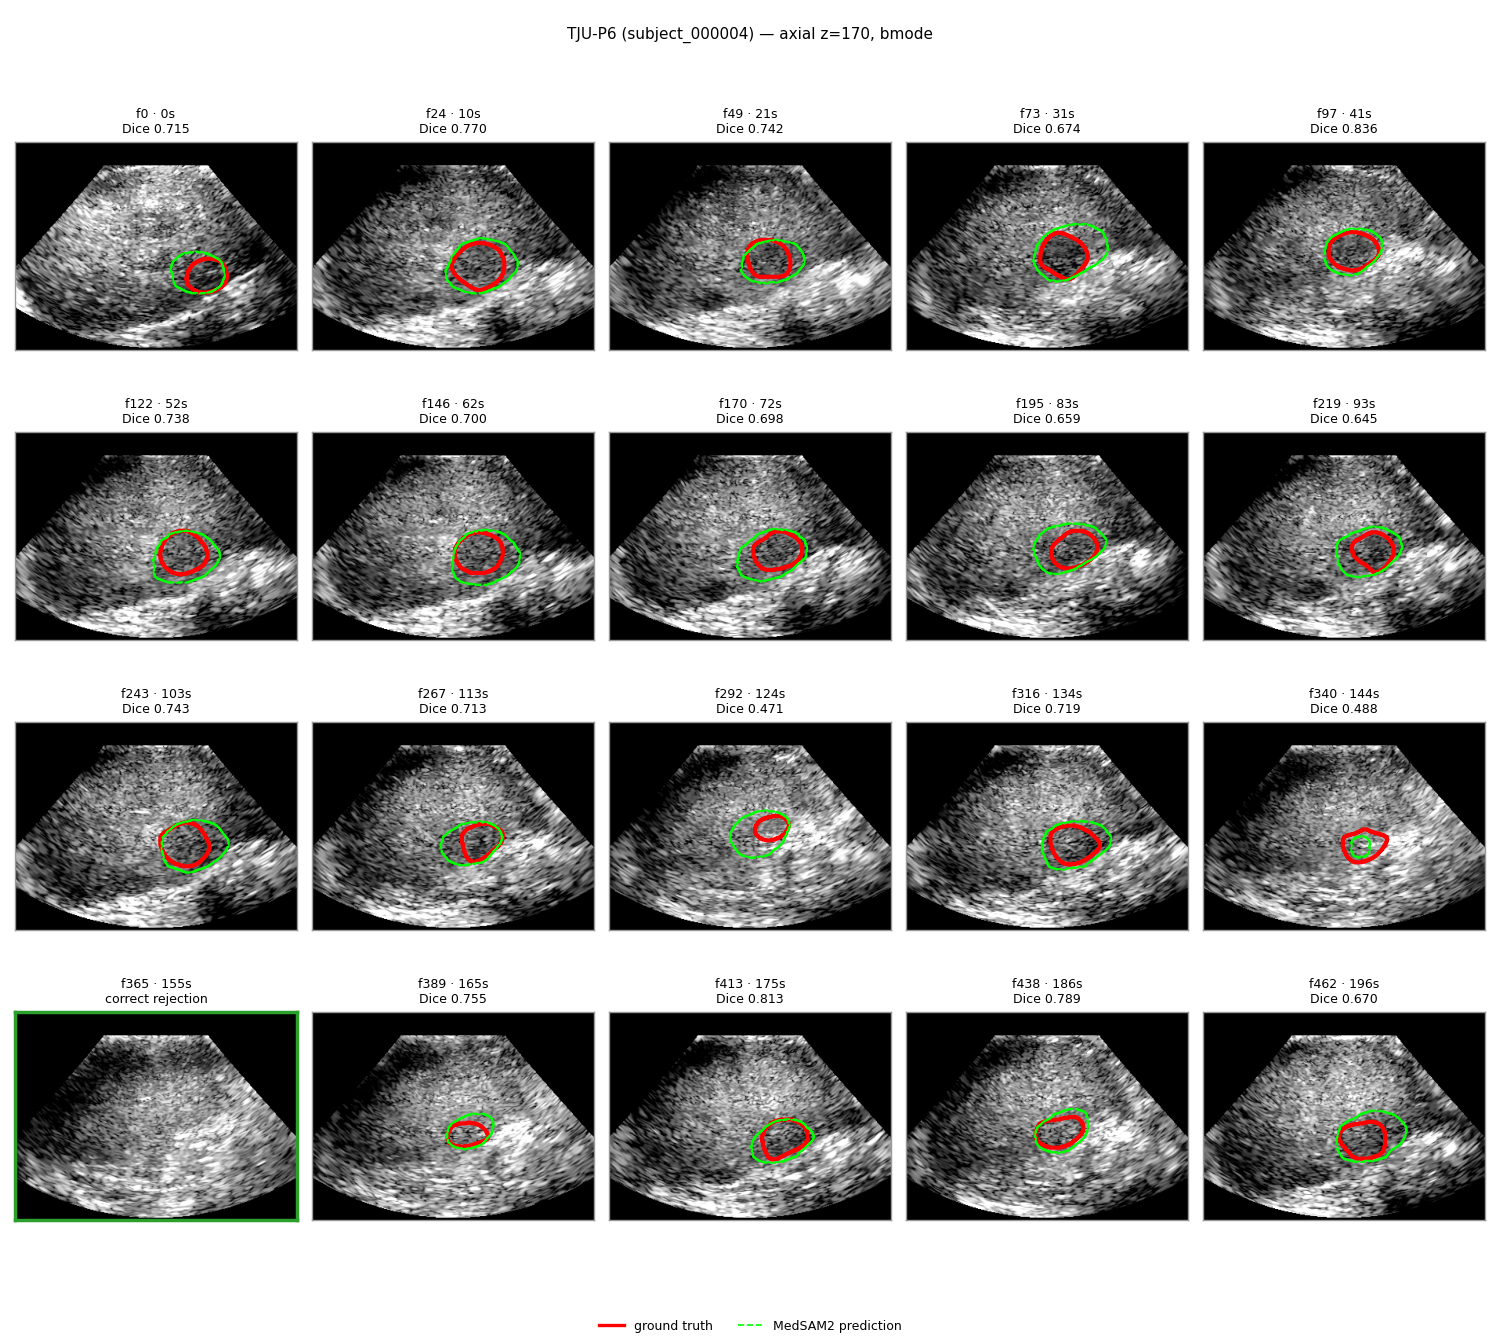

In [16]:
import matplotlib.pyplot as plt

fig = plot_2d_overlay(case_dir, rows, ncols=5)
plt.show()

### Dice over time

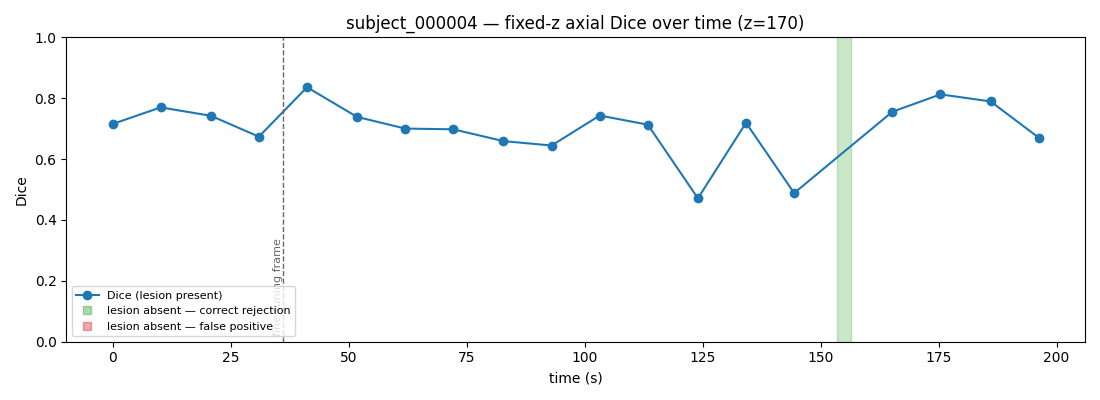

In [17]:
import matplotlib.pyplot as plt
from medsam2_2d_temporal_roi import load_2d_case

present = df[~df.gt_empty]
absent  = df[df.gt_empty]

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(present.time_s, present.dice, "o-", color="C0", label="Dice (lesion present)")
for r in absent.itertuples():
    ax.axvspan(r.time_s - 1.5, r.time_s + 1.5,
               color=("C2" if r.pred_empty else "C3"), alpha=0.25)
ax.plot([], [], "s", color="C2", alpha=0.4, label="lesion absent — correct rejection")
ax.plot([], [], "s", color="C3", alpha=0.4, label="lesion absent — false positive")

case_meta = load_2d_case(case_dir)
ft, rate = case_meta.get("finetune_frame_idx"), case_meta.get("frame_rate_hz")
if ft is not None and rate:
    ax.axvline(ft / rate, color="0.4", ls="--", lw=1)
    ax.annotate("fine-tuning frame", (ft / rate, 0.02),
                rotation=90, fontsize=8, color="0.4", va="bottom", ha="right")

ax.set_ylim(0, 1); ax.set_xlabel("time (s)"); ax.set_ylabel("Dice")
ax.set_title(f"{annotator.subject_id} — fixed-z axial Dice over time (z={annotator.z})")
ax.legend(loc="lower left", fontsize=8)
plt.tight_layout(); plt.show()

# Step 5 — Batch Processing to compare all the annotated 2D frames. AdaptiveBBox vs Axial Propagation

Scores all annotated cases under both reconstruction methods, on the **same
checkpoint and the same frames**, so the difference is attributable to the
method alone and the comparison is paired case by case.

Both go through one `evaluate_2d_dataset` call with two *variants* rather than
two separate calls — that is what tags each row with which method produced it,
so the summary and the paired table can tell them apart.

Each case loads its own reference VOI and B-mode series. The 4D volumes are
*not* materialised — `_LazyBmode` keeps nibabel's proxy and reads one frame at
a time (~0.1 s); loading them eagerly would be 7.4 GB each.

**This takes a while**, and the two methods are not equally fast. Adaptive-bbox
runs 2 guide calls plus one 2D call per axial slice per frame. Axial
propagation builds a full video tensor and runs two passes through the whole
axial stack per frame, so budget considerably longer for it. Smoke-test with
`cases=...[:3]` first.

In [14]:
from medsam2_2d_temporal_roi import evaluate_2d_dataset, discover_2d_cases
from medsam2_3d_mask import Medsam2AdaptiveBboxMasker
from medsam2_axial_propagation import Medsam2AxialPropagationViewer


OUTPUT_ROOT_2D    = "/media/ahmed-el-kaffas/20TB-HDD/Yuanshan/3DMPUS/MedSAM2_2D_temporal_eval"
FINETUNE_MANIFEST = "/media/ahmed-el-kaffas/20TB-HDD/Yuanshan/3DMPUS/MedSAM2_finetune_data/manifest.csv"

medsam2_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'MedSAM2'))
CHECKPOINT = os.path.join(medsam2_path, 'exp_log', '3DMPUS_liver_tumor',
                          'checkpoints', 'checkpoint.pt')
model_cfg  = "configs/sam2.1_hiera_t512.yaml"

NPZ_TRAIN = "/media/ahmed-el-kaffas/20TB-HDD/Yuanshan/3DMPUS/MedSAM2_finetune_data/npz_train"

VARIANTS = {
    "adaptive-bbox": {"masker_cls": Medsam2AdaptiveBboxMasker,
                      "checkpoint": CHECKPOINT,
                      "synthetic_coronal": False},   # True = axial+sagittal ellipse guide
    "axial-prop":    {"masker_cls": Medsam2AxialPropagationViewer,
                      "checkpoint": CHECKPOINT},     # takes no synthetic_coronal
}

print(f"checkpoint: {'OK ' if os.path.isfile(CHECKPOINT) else 'MISSING'} {CHECKPOINT}")
print(f"{len(discover_2d_cases(OUTPUT_ROOT_2D))} annotated case(s) found")

checkpoint: OK  /home/ahmed-el-kaffas/Documents/Github/QuantUS/MedSAM2/exp_log/3DMPUS_liver_tumor/checkpoints/checkpoint.pt
15 annotated case(s) found


In [17]:
rows = evaluate_2d_dataset(
    OUTPUT_ROOT_2D,
    VARIANTS,
    model_cfg,
    device="cuda",
    smooth_sigma_mm=1.0,    # applied to both; cross-z bleed corrupts the empty-frame test
    # cases=discover_2d_cases(OUTPUT_ROOT_2D)[:3],   # smoke test
)
print(f"\n{len(rows)} per-frame rows "
      f"({len({r['variant'] for r in rows})} variants x "
      f"{len({r['case'] for r in rows})} cases)")


=== adaptive-bbox: Medsam2AdaptiveBboxMasker @ checkpoint.pt ===
  [ 1/15] subject_000001_sequence_003_z0183  mean Dice 0.872  (20 present, 0 empty)
  [ 2/15] subject_000003_sequence_001_z0169  mean Dice 0.670  (20 present, 0 empty)
  [ 3/15] subject_000004_sequence_002_z0170  mean Dice 0.731  (19 present, 1 empty)
  [ 4/15] subject_000005_sequence_001_z0096  mean Dice 0.852  (20 present, 0 empty)
  [ 5/15] subject_000006_sequence_001_z0115  mean Dice 0.896  (20 present, 0 empty)


/home/ahmed-el-kaffas/Documents/Github/QuantUS/.venv/lib/python3.12/site-packages/monai/metrics/utils.py:347: UserWarning: the prediction of class 0 is all 0, this may result in nan/inf distance.
  warnings.warn(


  [ 6/15] subject_000007_sequence_003_z0118  mean Dice 0.763  (19 present, 1 empty)
  [ 7/15] subject_000008_sequence_001_z0114  mean Dice 0.782  (20 present, 0 empty)
  [ 8/15] subject_000009_sequence_001_z0117  mean Dice 0.694  (20 present, 0 empty)
  [ 9/15] subject_000009_sequence_002_z0108  mean Dice 0.816  (20 present, 0 empty)
  [10/15] subject_000009_sequence_003_z0086  mean Dice 0.921  (20 present, 0 empty)
  [11/15] subject_000009_sequence_004_z0099  mean Dice 0.919  (20 present, 0 empty)
  [12/15] subject_000009_sequence_005_z0125  mean Dice 0.816  (20 present, 0 empty)
  [13/15] subject_000009_sequence_006_z0114  mean Dice 0.679  (20 present, 0 empty)
  [14/15] subject_000010_sequence_001_z0065  mean Dice 0.705  (19 present, 1 empty)
  [15/15] subject_000010_sequence_005_z0069  mean Dice 0.887  (20 present, 0 empty)

=== axial-prop: Medsam2AxialPropagationViewer @ checkpoint.pt ===


propagate in video: 100%|██████████| 184/184 [00:02<00:00, 75.18it/s]


  [ 1/15] subject_000001_sequence_003_z0183  mean Dice 0.889  (20 present, 0 empty)


...

  [13/15] subject_000009_sequence_006_z0114  mean Dice 0.691  (20 present, 0 empty)


propagate in video: 100%|██████████| 71/71 [00:00<00:00, 79.42it/s]


  [14/15] subject_000010_sequence_001_z0065  mean Dice 0.691  (19 present, 1 empty)


propagate in video: 100%|██████████| 71/71 [00:00<00:00, 73.07it/s]


  [15/15] subject_000010_sequence_005_z0069  mean Dice 0.873  (20 present, 0 empty)

600 per-frame rows (2 variants x 15 cases)


## Metrics, mean ± SD

Four metrics, computed per frame by the same MONAI implementations the 3D
evaluator uses (`medsam2_gt_eval`), with each case's own mm spacing so the
distances are physical:

| | |
|---|---|
| **Dice** | overlap; size-biased, harsh on small cross-sections |
| **NSD @ 1.0 mm** | fraction of boundary within 1 mm — "is the contour within an acceptable margin", and not size-biased the way Dice is |
| **ASSD (mm)** | average symmetric surface distance — typical boundary error |
| **HD95 (mm)** | 95th-percentile Hausdorff — worst-case boundary error, ignoring the top 5% of outliers |

Dice and NSD go up, ASSD and HD95 go down. The tolerance is part of NSD's
name on purpose: an NSD quoted without it is unreadable.

**Watch the `frames` column — it differs between metrics, and that matters.**
When the lesion is present but the model predicts nothing, Dice scores it 0,
but a surface distance has no surface to measure from and comes back NaN. Those
frames therefore drop out of ASSD and HD95, which makes those two an average
over an easier subset than Dice. `n_missed` counts them; if it is non-zero,
ASSD/HD95 flatter the method that fails by predicting nothing.

Three levels of aggregation are reported. **Quote per-subject** —
`subject_000009` supplies 6 of the 15 cases, so it dominates any per-frame
number. Empty-GT frames have *undefined* geometry, not zero, so they are NaN
in every metric and appear only in the specificity column.

In [15]:
import pandas as pd
from medsam2_2d_temporal_roi import summarize_metrics, plot_variant_comparison, METRICS

summary = pd.DataFrame(summarize_metrics(rows, npz_train_dir=NPZ_TRAIN))

def pm(m, s):
    return "n/a" if pd.isna(m) else f"{m:.3f} ± {s:.3f}"

table = pd.DataFrame({
    "variant": summary.variant, "tier": summary.tier, "metric": summary.metric,
    "subjects": summary.n_subjects, "cases": summary.n_cases,
    "frames": summary.n_frames, "n_missed": summary.n_missed,
    "per frame":   [pm(m, s) for m, s in zip(summary.mean_per_frame,   summary.sd_per_frame)],
    "per case":    [pm(m, s) for m, s in zip(summary.mean_per_case,    summary.sd_per_case)],
    "per subject": [pm(m, s) for m, s in zip(summary.mean_per_subject, summary.sd_per_subject)],
})
display(table[table.tier == "all"])
display(table[table.tier != "all"])

spec = summary[summary.metric == "dice"][["variant", "tier", "n_absent", "specificity"]]
print("\nempty-GT frames (lesion out of plane) — detection, not geometry:")
display(spec)

df = pd.DataFrame(rows)
out_csv = f"{OUTPUT_ROOT_2D}/metrics_by_frame.csv"
df.drop(columns=[c for c in ("gt_mask", "pred_mask") if c in df], errors="ignore").to_csv(out_csv, index=False)
print(f"per-frame results -> {out_csv}")

NameError: name 'rows' is not defined

## Figure — paired per-subject comparison

One panel per metric. Each line is **one subject**, joining its mean under one
variant to its mean under the other; red = holdout, blue = train. The black
square is the mean ± SD across subjects.

Paired lines rather than two bars, because both variants ran on identical
frames with identical weights — so what matters is whether each *subject*
moved and in which direction, which a pair of summary bars hides completely.
With 9 subjects the direction and consistency of the lines (`k/n favour ...`
under each panel) carry more than the error bars do.

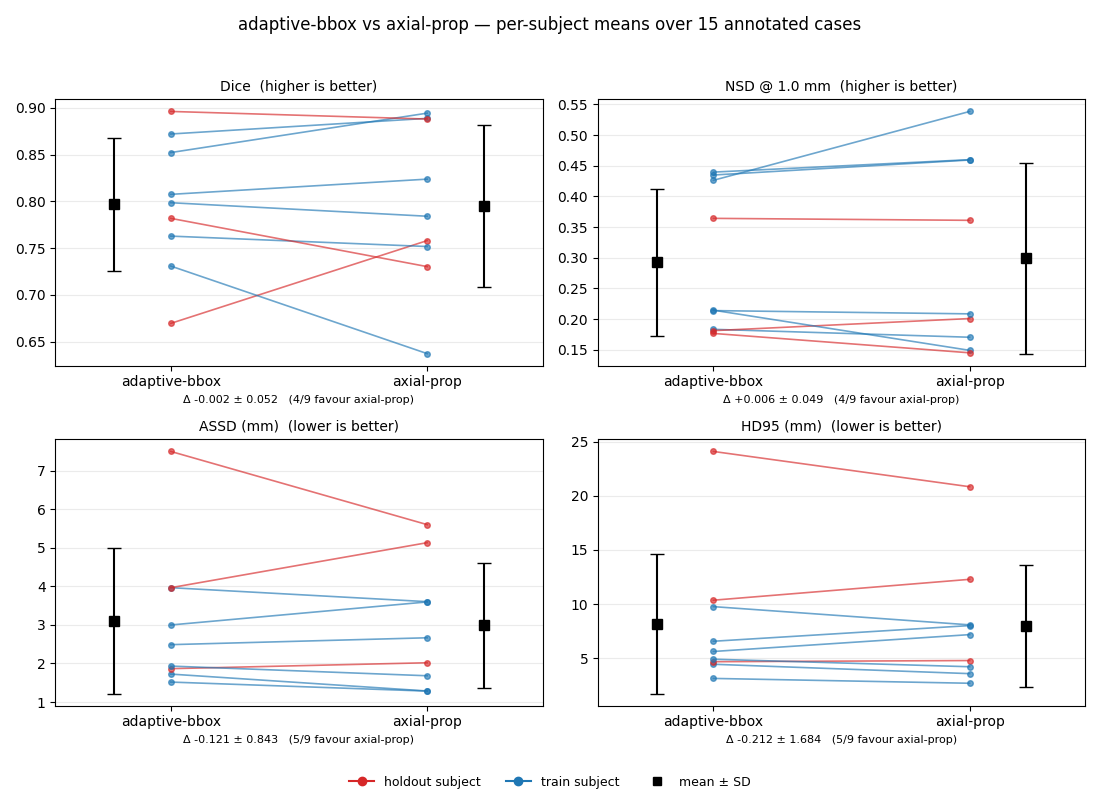

figure -> /media/ahmed-el-kaffas/20TB-HDD/Yuanshan/3DMPUS/MedSAM2_2D_temporal_eval/variant_comparison.png


In [20]:
import matplotlib.pyplot as plt
fig = plot_variant_comparison(rows, npz_train_dir=NPZ_TRAIN)
fig.savefig(f"{OUTPUT_ROOT_2D}/variant_comparison.png", dpi=200, bbox_inches="tight")
plt.show()
print(f"figure -> {OUTPUT_ROOT_2D}/variant_comparison.png")

### Per-subject numbers behind the figure

In [21]:
from medsam2_2d_temporal_roi import per_subject_table

for metric in METRICS:
    t = pd.DataFrame(per_subject_table(rows, metric, NPZ_TRAIN)).T
    variants = [c for c in t.columns if c != "tier"]
    t["delta"] = t[variants[1]] - t[variants[0]]
    print(f"\n=== {metric} ===")
    display(t[[*variants, "delta", "tier"]].round(3))


=== dice ===


,adaptive-bbox,axial-prop,delta,tier
subject_000001,0.871932,0.888624,0.016691,train
subject_000003,0.669697,0.758091,0.088394,holdout
subject_000004,0.73089,0.637401,-0.093489,train
subject_000005,0.852104,0.894182,0.042077,train
subject_000006,0.89601,0.88789,-0.00812,holdout
subject_000007,0.762877,0.751752,-0.011125,train
subject_000008,0.781839,0.730309,-0.05153,holdout
subject_000009,0.807463,0.823724,0.01626,train
subject_000010,0.798537,0.784101,-0.014435,train



=== nsd@1.0mm ===


,adaptive-bbox,axial-prop,delta,tier
subject_000001,0.183255,0.170355,-0.012901,train
subject_000003,0.181094,0.200819,0.019725,holdout
subject_000004,0.214482,0.148976,-0.065507,train
subject_000005,0.426178,0.538499,0.112321,train
subject_000006,0.36418,0.360971,-0.003209,holdout
subject_000007,0.213787,0.208472,-0.005315,train
subject_000008,0.176581,0.144964,-0.031618,holdout
subject_000009,0.434842,0.459317,0.024475,train
subject_000010,0.439589,0.459861,0.020272,train



=== assd_mm ===


,adaptive-bbox,axial-prop,delta,tier
subject_000001,3.965765,3.603254,-0.362511,train
subject_000003,7.499083,5.601082,-1.898001,holdout
subject_000004,2.998847,3.596217,0.59737,train
subject_000005,1.724791,1.286569,-0.438223,train
subject_000006,1.865814,2.018759,0.152945,holdout
subject_000007,2.488431,2.66664,0.178209,train
subject_000008,3.965619,5.132716,1.167098,holdout
subject_000009,1.932545,1.681529,-0.251016,train
subject_000010,1.517969,1.283862,-0.234107,train



=== hd95_mm ===


,adaptive-bbox,axial-prop,delta,tier
subject_000001,9.767824,8.086053,-1.68177,train
subject_000003,24.083465,20.827958,-3.255507,holdout
subject_000004,6.572146,8.018925,1.446779,train
subject_000005,4.451102,3.585878,-0.865225,train
subject_000006,4.687071,4.793602,0.106531,holdout
subject_000007,5.629278,7.184593,1.555315,train
subject_000008,10.359645,12.285878,1.926233,holdout
subject_000009,4.916469,4.222335,-0.694134,train
subject_000010,3.144807,2.69832,-0.446487,train
